In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Primera planta
Se va a comenzar el data cleaning con la primera planta


In [80]:
p1gen = pd.read_csv('../data/raw/Plant_1_Generation_Data.csv')
p1gen.info()
p1gen.head()

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  str    
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  str    
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 3.7 MB


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [81]:
p1weather = pd.read_csv('../data/raw/Plant_1_Weather_Sensor_Data.csv')
p1weather.info()
p1weather.head()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   str    
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   str    
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION          3182 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 149.3 KB


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


Se le va a dar formato de fecha a DATE_TIME e igularlos en generación y clima

In [82]:
p1gen['DATE_TIME'] = pd.to_datetime(p1gen['DATE_TIME'], format="%d-%m-%Y %H:%M")
p1gen

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.000,6259559.0
1,2020-05-15 00:00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.000,6183645.0
2,2020-05-15 00:00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.000,6987759.0
3,2020-05-15 00:00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.000,7602960.0
4,2020-05-15 00:00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.000,7158964.0
...,...,...,...,...,...,...,...
68773,2020-06-17 23:45:00,4135001,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68774,2020-06-17 23:45:00,4135001,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68775,2020-06-17 23:45:00,4135001,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68776,2020-06-17 23:45:00,4135001,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0


In [83]:
p1weather['DATE_TIME'] = pd.to_datetime(p1weather['DATE_TIME'], format="%Y-%m-%d %H:%M:%S")
p1weather['DATE_TIME'] = p1weather['DATE_TIME'].dt.strftime('%d,%m,%Y %H:%M:%S')
p1weather['DATE_TIME'] = pd.to_datetime(p1weather['DATE_TIME'], format="%d,%m,%Y %H:%M:%S")
p1weather

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0
...,...,...,...,...,...,...
3177,2020-06-17 22:45:00,4135001,HmiyD2TTLFNqkNe,22.150570,21.480377,0.0
3178,2020-06-17 23:00:00,4135001,HmiyD2TTLFNqkNe,22.129816,21.389024,0.0
3179,2020-06-17 23:15:00,4135001,HmiyD2TTLFNqkNe,22.008275,20.709211,0.0
3180,2020-06-17 23:30:00,4135001,HmiyD2TTLFNqkNe,21.969495,20.734963,0.0


In [84]:
p1gen.info()
print("---------------\n----------------")
p1weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    68778 non-null  datetime64[us]
 1   PLANT_ID     68778 non-null  int64         
 2   SOURCE_KEY   68778 non-null  str           
 3   DC_POWER     68778 non-null  float64       
 4   AC_POWER     68778 non-null  float64       
 5   DAILY_YIELD  68778 non-null  float64       
 6   TOTAL_YIELD  68778 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 3.7 MB
---------------
----------------
<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3182 non-null   datetime64[us]
 1   PLANT_ID             3182 non-null   int64         
 2   SOURCE_KEY           318

DATE_TIME ahora estan en el mismo orden y en formato datetime64[us]

In [85]:
print('SOURCE_KEY',p1weather['SOURCE_KEY'].unique())
print("---------------\n----------------")
print('PLANT_ID',p1weather['PLANT_ID'].unique())
print("---------------\n----------------")
print("PLANT_ID gen",p1gen['PLANT_ID'].unique())
print("---------------\n----------------")
print("SOURCE_KEY gen",p1gen['SOURCE_KEY'].unique())


SOURCE_KEY <StringArray>
['HmiyD2TTLFNqkNe']
Length: 1, dtype: str
---------------
----------------
PLANT_ID [4135001]
---------------
----------------
PLANT_ID gen [4135001]
---------------
----------------
SOURCE_KEY gen <StringArray>
['1BY6WEcLGh8j5v7', '1IF53ai7Xc0U56Y', '3PZuoBAID5Wc2HD', '7JYdWkrLSPkdwr4',
 'McdE0feGgRqW7Ca', 'VHMLBKoKgIrUVDU', 'WRmjgnKYAwPKWDb', 'ZnxXDlPa8U1GXgE',
 'ZoEaEvLYb1n2sOq', 'adLQvlD726eNBSB', 'bvBOhCH3iADSZry', 'iCRJl6heRkivqQ3',
 'ih0vzX44oOqAx2f', 'pkci93gMrogZuBj', 'rGa61gmuvPhdLxV', 'sjndEbLyjtCKgGv',
 'uHbuxQJl8lW7ozc', 'wCURE6d3bPkepu2', 'z9Y9gH1T5YWrNuG', 'zBIq5rxdHJRwDNY',
 'zVJPv84UY57bAof', 'YxYtjZvoooNbGkE']
Length: 22, dtype: str


Solo hay un 'SOURCE_KEY' y "PLANT_ID' en los datos de clima y un solo "PLANT_ID" en los datos de generacion , por lo que esas columnas se van a eliminar

In [86]:
p1weather = p1weather.drop(columns=['SOURCE_KEY'])
p1weather = p1weather.drop(columns=['PLANT_ID'])
p1weather.info()
print("---------------\n----------------")
p1gen = p1gen.drop(columns=['PLANT_ID'])
p1gen.info()

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3182 non-null   datetime64[us]
 1   AMBIENT_TEMPERATURE  3182 non-null   float64       
 2   MODULE_TEMPERATURE   3182 non-null   float64       
 3   IRRADIATION          3182 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 99.6 KB
---------------
----------------
<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   DATE_TIME    68778 non-null  datetime64[us]
 1   SOURCE_KEY   68778 non-null  str           
 2   DC_POWER     68778 non-null  float64       
 3   AC_POWER     68778 non-null  float64       
 4   DAILY_YIELD  68778 non-null  float64       
 5   TOTAL_YIELD  68778 non-nu

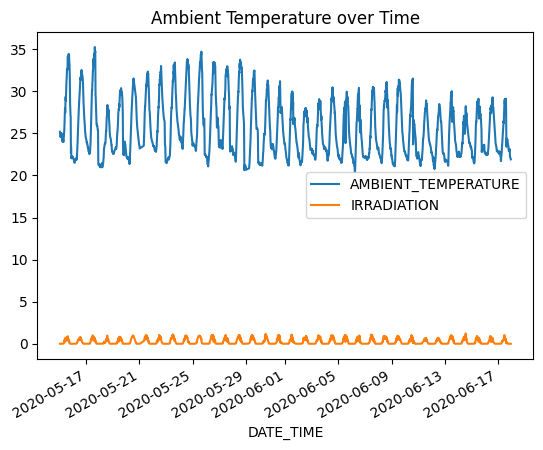

In [87]:
p1weather.plot(x='DATE_TIME', y=['AMBIENT_TEMPERATURE','IRRADIATION'], title='Ambient Temperature over Time')
plt.show()

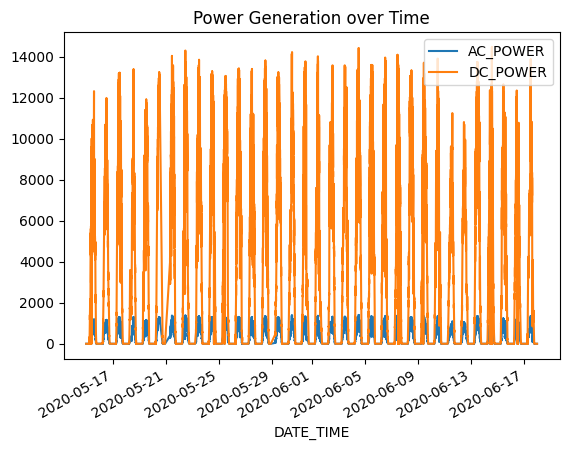

In [88]:
p1gen.plot(x='DATE_TIME', y=['AC_POWER','DC_POWER'], title='Power Generation over Time')
plt.show()

In [ ]:
p1_merged = pd.merge(p1gen, p1weather, on='DATE_TIME')
p1_merged.plot(x='DATE_TIME', y=['IRRADIATION', 'AC_POWER'], title='Irradiation and AC Power over Time')
plt.show()

Se guarda la información de la primera planta

In [30]:
p1gen.to_csv( '../data/processed/Plant_1_Generation_Data.csv', index=False)
p1weather.to_csv( '../data/processed/Plant_1_Weather_Sensor_Data.csv', index=False)

Agregar la información de la segunda planta

In [27]:
p2gen = pd.read_csv('../data/raw/Plant_2_Generation_Data.csv')
p2gen.info()
p2gen.head()

<class 'pandas.DataFrame'>
RangeIndex: 67698 entries, 0 to 67697
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    67698 non-null  str    
 1   PLANT_ID     67698 non-null  int64  
 2   SOURCE_KEY   67698 non-null  str    
 3   DC_POWER     67698 non-null  float64
 4   AC_POWER     67698 non-null  float64
 5   DAILY_YIELD  67698 non-null  float64
 6   TOTAL_YIELD  67698 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 3.6 MB


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
1,2020-05-15 00:00:00,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2,2020-05-15 00:00:00,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09
3,2020-05-15 00:00:00,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06
4,2020-05-15 00:00:00,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07


In [28]:
p2wather = pd.read_csv('../data/raw/Plant_2_Weather_Sensor_Data.csv')
p2wather.info()
p2wather.head()

<class 'pandas.DataFrame'>
RangeIndex: 3259 entries, 0 to 3258
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3259 non-null   str    
 1   PLANT_ID             3259 non-null   int64  
 2   SOURCE_KEY           3259 non-null   str    
 3   AMBIENT_TEMPERATURE  3259 non-null   float64
 4   MODULE_TEMPERATURE   3259 non-null   float64
 5   IRRADIATION          3259 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 152.9 KB


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4136001,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,4136001,iq8k7ZNt4Mwm3w0,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,4136001,iq8k7ZNt4Mwm3w0,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,4136001,iq8k7ZNt4Mwm3w0,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,4136001,iq8k7ZNt4Mwm3w0,26.596148,25.088210,0.0


In [34]:
for i in ['PLANT_ID', 'SOURCE_KEY']:
    print(i)
    print(p2wather[i].unique())

PLANT_ID
[4136001]
SOURCE_KEY
<StringArray>
['iq8k7ZNt4Mwm3w0']
Length: 1, dtype: str


In [35]:
for i in ['PLANT_ID', 'SOURCE_KEY']:
    print(i)
    print(p2gen[i].unique())

PLANT_ID
[4136001]
SOURCE_KEY
<StringArray>
['4UPUqMRk7TRMgml', '81aHJ1q11NBPMrL', '9kRcWv60rDACzjR', 'Et9kgGMDl729KT4',
 'IQ2d7wF4YD8zU1Q', 'LYwnQax7tkwH5Cb', 'LlT2YUhhzqhg5Sw', 'Mx2yZCDsyf6DPfv',
 'NgDl19wMapZy17u', 'PeE6FRyGXUgsRhN', 'Qf4GUc1pJu5T6c6', 'Quc1TzYxW2pYoWX',
 'V94E5Ben1TlhnDV', 'WcxssY2VbP4hApt', 'mqwcsP2rE7J0TFp', 'oZ35aAeoifZaQzV',
 'oZZkBaNadn6DNKz', 'q49J1IKaHRwDQnt', 'rrq4fwE8jgrTyWY', 'vOuJvMaM2sgwLmb',
 'xMbIugepa2P7lBB', 'xoJJ8DcxJEcupym']
Length: 22, dtype: str
